In [1]:
setwd("~/Projects/R/ISLR2")

In [2]:
source("InstallAndLoadScripts/loadlibraries.R")

In [3]:
loadISLR2Libraries()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ dplyr::select() masks MASS::select()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘ISLR2’


The following object is masked from ‘package:MASS’:

    Boston


Loading required package: ggpp

Registered S3 methods overwritten by 'ggpp':
  method                  from   
  heightDetails.titleGrob ggplot2
  widthDetails.titleGrob  ggplot2


Attaching package: ‘ggpp’


The following object is masked from ‘package:ggplot2’:

    annotate



Attaching package: ‘gridExtra’


The following object is mas

In [4]:
installNeuralLibraries()


The downloaded binary packages are in
	/var/folders/h7/hn_c9vcj37s8lll1bfs2mgfm0000gn/T//RtmpwEYPnN/downloaded_packages


In [17]:
loadNeuralLibraries()

In [18]:
Gitters <- na.omit(Hitters)

In [19]:
x <- scale( model.matrix (Salary ~ . - 1, data = Gitters))

In [20]:
y <- Gitters$Salary

In [21]:
n <- nrow(Gitters)

In [22]:
set.seed (13)

In [23]:
ntest <- trunc(n / 3)

In [24]:
testid <- sample (1:n, ntest)

In [25]:
lfit <- lm(Salary ~ ., data = Gitters[-testid,])

In [26]:
cvfit <- cv.glmnet(x[-testid,], y[-testid],type.measure = "mae")

In [27]:
cpred <- predict(cvfit, x[testid,], s = "lambda.min")

In [28]:
mean(abs(y[testid] - cpred))

[1] 255.5094

In [29]:
modnn = keras_model_sequential() %>%
    layer_dense(units=50, activation="relu",
    input_shape=ncol(x)) %>%
    layer_dropout(rate=0.4) %>%
    layer_dense(units=1)

In [30]:
x <- model.matrix (Salary ~ . - 1, data = Gitters) %>% scale ()

In [31]:
modnn %>% compile(loss = "mse",
    optimizer = optimizer_rmsprop (),
    metrics = list("mean_absolute_error"))

In [32]:
history <- modnn %>% fit(
    x[-testid,], y[-testid], epochs = 1500, batch_size = 32,
    validation_data = list(x[testid,], y[testid]))

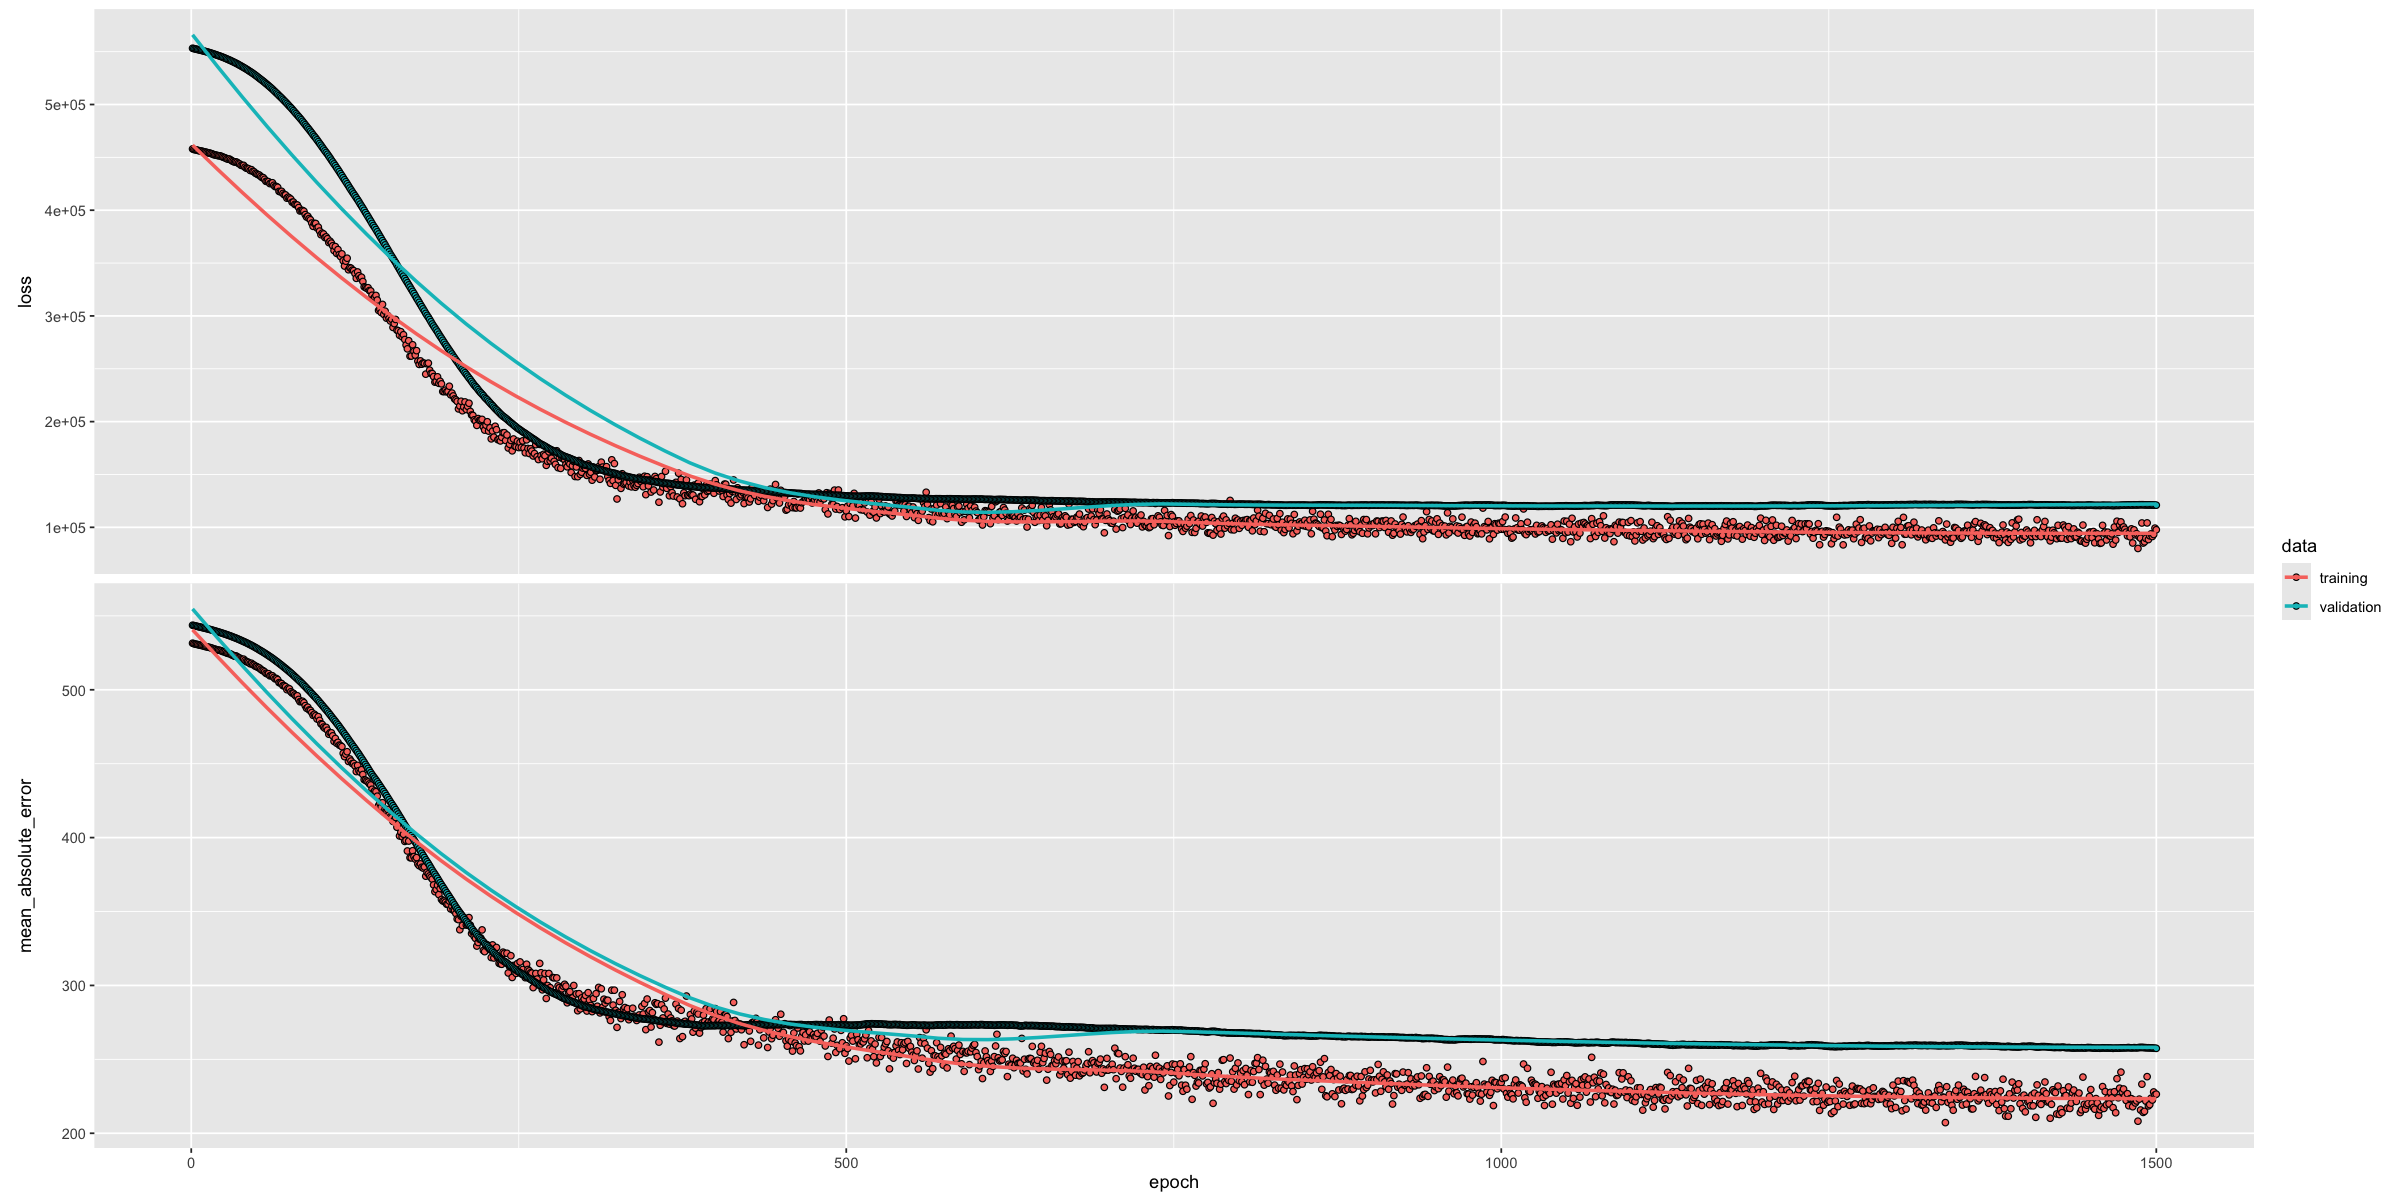

In [33]:
options(repr.plot.width = 20, repr.plot.height =10)
plot(history)